In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance, ExifTags

from IPython.display import display, Markdown, HTML, clear_output
import ipywidgets as widgets

%matplotlib inline


In [5]:
# Shared helper utilities

def make_demo_image(width=960, height=540):
    """Create a synthetic image for demos."""
    # Create gradient channels with matching shapes
    x = np.linspace(0, 1, width)
    y = np.linspace(0, 1, height)

    r = np.tile(x, (height, 1)) * 255
    g = np.tile(y[:, None], (1, width)) * 255
    b = (1 - np.tile(x, (height, 1))) * 255

    img = np.stack([r, g, b], axis=2).astype(np.uint8)

    # Draw shapes
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    cv2.circle(img_bgr, (int(width * 0.3), int(height * 0.5)), 80, (255, 255, 255), 5)
    cv2.rectangle(img_bgr, (int(width * 0.6), int(height * 0.3)), (int(width * 0.9), int(height * 0.7)), (0, 0, 0), 5)
    cv2.putText(img_bgr, "Vision Demo", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, (30, 30, 30), 3)

    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)



def pil_to_np(image: Image.Image) -> np.ndarray:
    return np.array(image.convert("RGB"))


def np_to_pil(arr: np.ndarray) -> Image.Image:
    return Image.fromarray(arr.astype(np.uint8))


def letterbox_image(image, size=(320, 320)):
    """Resize image with unchanged aspect ratio using padding."""
    ih, iw = image.shape[:2]
    h, w = size

    scale = min(w / iw, h / ih)
    nw = int(iw * scale)
    nh = int(ih * scale)

    resized = cv2.resize(image, (nw, nh))

    new_image = np.full((h, w, 3), 128, dtype=np.uint8)
    top = (h - nh) // 2
    left = (w - nw) // 2
    new_image[top:top+nh, left:left+nw] = resized

    return new_image, scale, (left, top), (nw, nh)


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

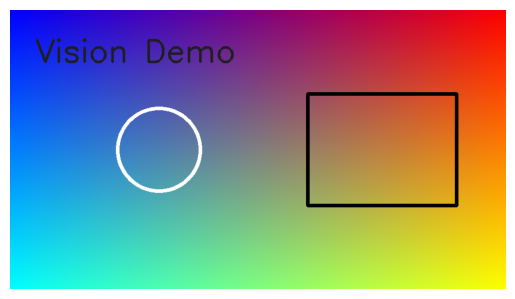

In [6]:
img = make_demo_image()
plt.imshow(img)
plt.axis("off")


(np.float64(-0.5), np.float64(319.5), np.float64(319.5), np.float64(-0.5))

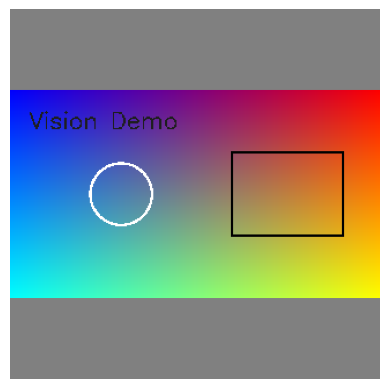

In [7]:
letter, ratio, pad, shape = letterbox_image(img, (320, 320))
plt.imshow(letter)
plt.axis("off")


(np.float64(-0.5), np.float64(319.5), np.float64(319.5), np.float64(-0.5))

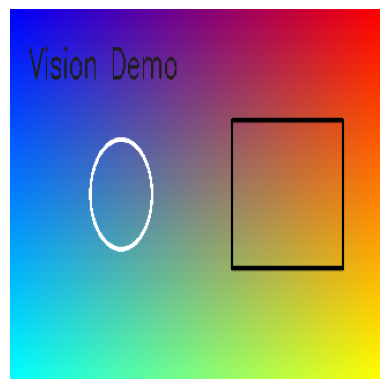

In [8]:
resized = cv2.resize(img, (320, 320))
plt.imshow(resized)
plt.axis("off")


(np.float64(-0.5), np.float64(319.5), np.float64(319.5), np.float64(-0.5))

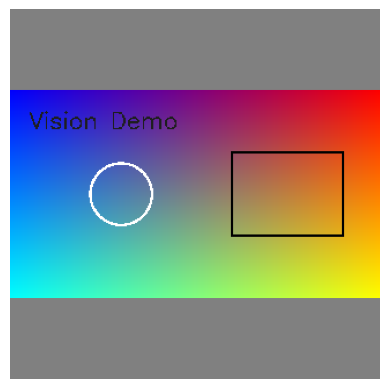

In [9]:
letter, ratio, pad, shape = letterbox_image(img, (320, 320))
plt.imshow(letter)
plt.axis("off")


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

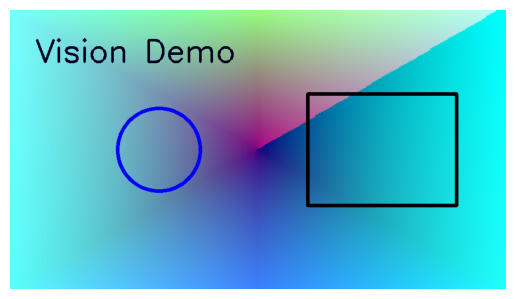

In [10]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
plt.imshow(hsv)
plt.axis("off")


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

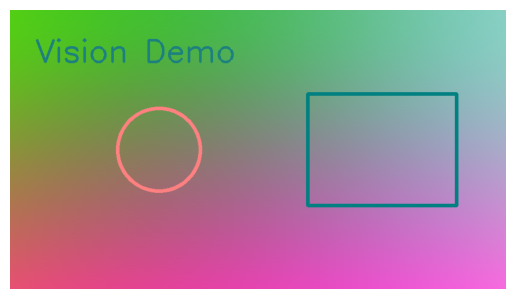

In [11]:
lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
plt.imshow(lab)
plt.axis("off")


In [12]:
def apply_gamma(image, gamma):
    inv = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

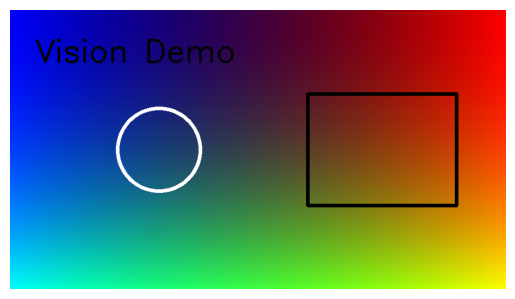

In [13]:
gamma_05 = apply_gamma(img, 0.5)
plt.imshow(gamma_05)
plt.axis("off")


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

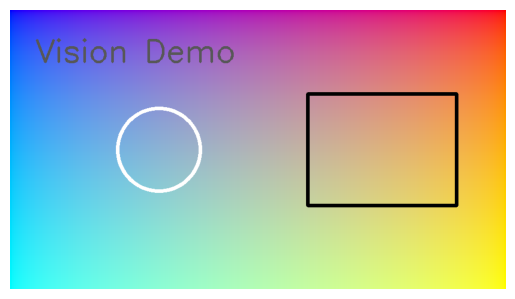

In [14]:
gamma_20 = apply_gamma(img, 2.0)
plt.imshow(gamma_20)
plt.axis("off")


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

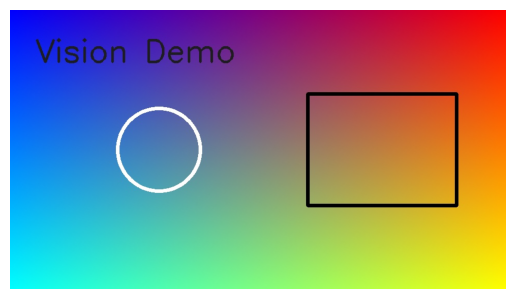

In [15]:
# JPEG quality 95
encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 95]
_, encimg = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR), encode_param)
jpeg95 = cv2.cvtColor(cv2.imdecode(encimg, 1), cv2.COLOR_BGR2RGB)

plt.imshow(jpeg95)
plt.axis("off")


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

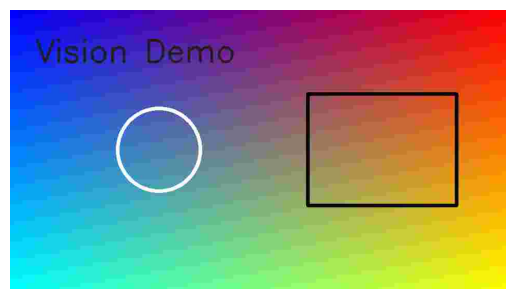

In [16]:
# JPEG quality 10
encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 10]
_, encimg = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR), encode_param)
jpeg10 = cv2.cvtColor(cv2.imdecode(encimg, 1), cv2.COLOR_BGR2RGB)

plt.imshow(jpeg10)
plt.axis("off")


In [17]:
def plot_hist(image, title="Histogram"):
    plt.figure(figsize=(6,4))
    colors = ("r", "g", "b")
    for i, col in enumerate(colors):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Count")
    plt.xlim([0, 256])
    plt.show()


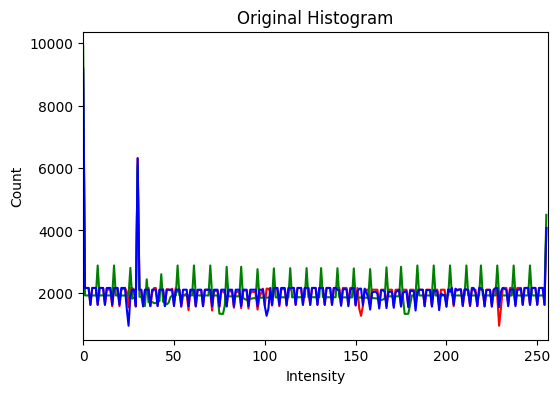

In [18]:
plot_hist(img, "Original Histogram")


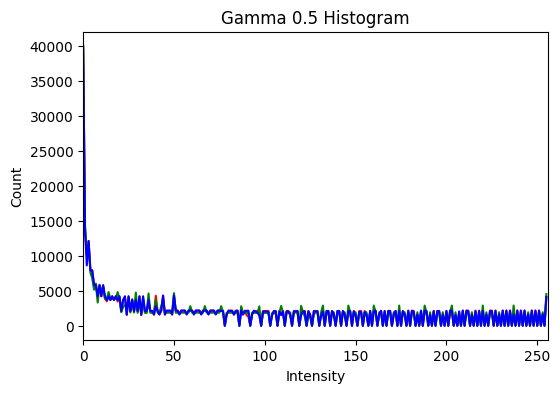

In [19]:
plot_hist(gamma_05, "Gamma 0.5 Histogram")


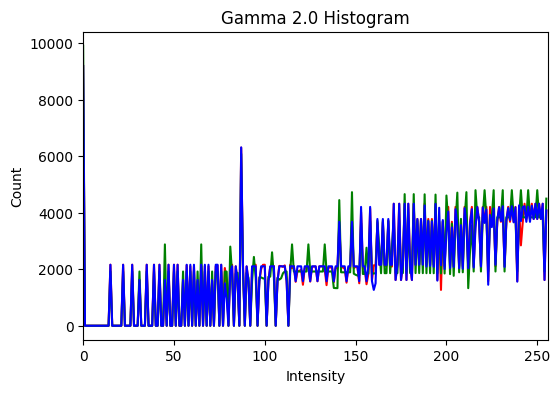

In [20]:
plot_hist(gamma_20, "Gamma 2.0 Histogram")
